In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt

from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianBuffer
from bvhgs.rasterizer import Rasterizer

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


# Create Gaussian Buffer

In [2]:
gaussians = GaussianBuffer(16)
len(gaussians)

16

In [3]:
gaussians[0]

{'position': array([0.91247153, 0.83031386, 0.13654463], dtype=float32),
 'rotation': array([0.59852016, 0.17814502, 0.15769085, 0.7604256 ], dtype=float32),
 'scale': array([0.34122133, 0.10589139, 0.8006672 ], dtype=float32),
 'color': array([0.98656434, 0.04583818, 0.46399334], dtype=float32),
 'opacity': 0.7272876501083374,
 'sh': [array([0.67484236, 0.14454515, 0.7076355 ], dtype=float32),
  array([0.9247584, 0.489397 , 0.4977904], dtype=float32),
  array([0.90956783, 0.7251948 , 0.9961393 ], dtype=float32),
  array([0.7949272 , 0.9203675 , 0.92094135], dtype=float32),
  array([0.07048012, 0.21106963, 0.45792964], dtype=float32),
  array([0.7897135 , 0.6455729 , 0.36722517], dtype=float32),
  array([0.5759548, 0.0501236, 0.6176173], dtype=float32),
  array([0.13360518, 0.6723806 , 0.7637066 ], dtype=float32),
  array([0.3911295 , 0.3641422 , 0.08678012], dtype=float32),
  array([0.2944449, 0.9842607, 0.7483376], dtype=float32),
  array([0.38936257, 0.77347225, 0.15289332], dtype=f

# Create Camera

In [4]:
camera = Camera(
    rotation=glm.quat(1, 0, 0, 0),
    translation=glm.vec3(0, 0, 1),
    sensor_size=glm.uvec2(512, 512),
    focal_length=256
)

# Create Buffer

In [5]:
program = device.load_program(
    "rasterizer.slang", entry_point_names=["render"]
)
kernel = device.create_compute_kernel(program)

In [6]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=kernel.reflection.g_gaussians,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    kernel.reflection.g_gaussians.type_layout.element_type_layout,
    gaussian_buf,
)

In [7]:
gaussian_cursor[0].read()

{'position': {0, 0, 0},
 'rotation': {0, 0, 0, 0},
 'scale': {0, 0, 0},
 'color': {0, 0, 0},
 'opacity': 0.0,
 'sh': [{0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0}]}

In [8]:
gaussian_cursor[0].write(gaussians[0])
gaussian_cursor.apply()

In [9]:
gaussian_cursor[0].read()

{'position': {0.91247153, 0.83031386, 0.13654463},
 'rotation': {0.59852016, 0.17814502, 0.15769085, 0.7604256},
 'scale': {0.34122133, 0.10589139, 0.8006672},
 'color': {0.98656434, 0.04583818, 0.46399334},
 'opacity': 0.7272876501083374,
 'sh': [{0.67484236, 0.14454515, 0.7076355},
  {0.9247584, 0.489397, 0.4977904},
  {0.90956783, 0.7251948, 0.9961393},
  {0.7949272, 0.9203675, 0.92094135},
  {0.07048012, 0.21106963, 0.45792964},
  {0.7897135, 0.6455729, 0.36722517},
  {0.5759548, 0.050123602, 0.6176173},
  {0.13360518, 0.6723806, 0.7637066},
  {0.3911295, 0.3641422, 0.086780116},
  {0.2944449, 0.9842607, 0.7483376},
  {0.38936257, 0.77347225, 0.15289332},
  {0.48181134, 0.9349331, 0.40877274},
  {0.42580798, 0.7394141, 0.83947366},
  {0.40781757, 0.8111152, 0.9261155},
  {0.12325455, 0.27682698, 0.68452865}]}

# Rasterizer

In [10]:
rasterizer = Rasterizer(gaussians, camera)

In [11]:
rasterizer.render()

In [12]:
res = rasterizer.render_target.to_bitmap()
print(res)

Bitmap(
  pixel_format = rgba,
  component_type = float32,
  width = 512,
  height = 512,
  srgb_gamma = false,
  pixel_struct = DataStruct(
    pack = true,
    byte_order = little_endian,
    fields = [
      Field(name="R", type=float32, flags=none, size=4, offset=0),
      Field(name="G", type=float32, flags=none, size=4, offset=4),
      Field(name="B", type=float32, flags=none, size=4, offset=8),
      Field(name="A", type=float32, flags=none, size=4, offset=12),
    ],
    size = 16,
    alignment = 1
  ),
  data = 4.00 MB
)


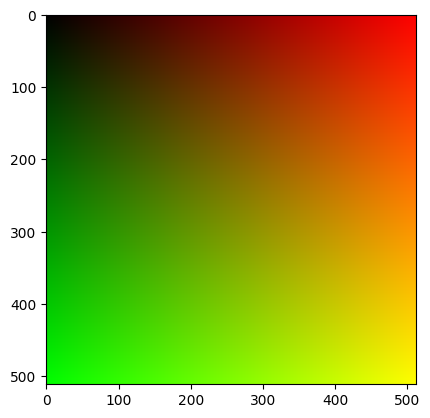

In [13]:
plt.imshow(res)